In [1]:
# Fix: two libgomp builds (torch.libs + scikit_learn.libs) conflict at init time,
# which can kill the kernel with ExitCode: undefined. Pin to 1 thread before any import.
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# IMFACT Counterfactual Walkthrough in UMAP Space

This notebook traces the **distance** mode of `cfts.cf_imfact.imfact` step by step.

It shows:
- the original query sample
- the native guide chosen by the IMFACT search
- intermediate reconstructions produced by the IMF weight updates
- the final counterfactual projected into 2D with UMAP

The background points come from the full FruitFlies train+test corpus.
The notebook also compares the traced path against the actual `imfact_cf` output so you can see the same method in action.

In [2]:
from pathlib import Path
import random
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import umap
from scipy.spatial.distance import jensenshannon

from cfts.cf_imfact.imfact import _psd, _sift_imfs, imfact_cf, trace_imfact_variant_path

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'cfts').exists():
        sys.path.insert(0, str(candidate))
        sys.path.insert(0, str(candidate / 'examples'))
        break

from base.data import get_UCR_UEA_dataloader
from base.model import SimpleCNN

warnings.filterwarnings(
    'ignore',
    message='n_jobs value 1 overridden to 1 by setting random_state.*',
    category=UserWarning,
    module='umap.umap_'
)

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'cfts').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root.')

def to_channel_first(sample: np.ndarray) -> np.ndarray:
    arr = np.asarray(sample, dtype=np.float32)
    if arr.ndim == 1:
        return arr.reshape(1, -1)
    if arr.ndim == 2:
        if arr.shape[0] > arr.shape[1]:
            return arr.T
        return arr
    if arr.ndim == 3 and arr.shape[0] == 1:
        return arr[0]
    raise ValueError(f'Unsupported shape for plotting: {arr.shape}')

def to_class_index(label) -> int:
    arr = np.asarray(label)
    if arr.ndim == 0:
        return int(arr)
    return int(np.argmax(arr))

def predict_scores(model: torch.nn.Module, sample: np.ndarray, device: torch.device) -> np.ndarray:
    tensor = torch.tensor(sample, dtype=torch.float32, device=device)
    if tensor.ndim == 1:
        tensor = tensor.reshape(1, 1, -1)
    elif tensor.ndim == 2:
        if tensor.shape[0] > tensor.shape[1]:
            tensor = tensor.T
        tensor = tensor.unsqueeze(0)
    with torch.no_grad():
        return model(tensor).cpu().numpy().reshape(-1)

def select_first_correct_sample(model: torch.nn.Module, dataset, device: torch.device):
    for idx in range(len(dataset)):
        sample, label = dataset[idx]
        scores = predict_scores(model, np.asarray(sample, dtype=np.float32), device)
        pred_class = int(np.argmax(scores))
        true_class = to_class_index(label)
        if pred_class == true_class:
            sorted_classes = np.argsort(scores)[::-1]
            target_class = next((int(c) for c in sorted_classes if int(c) != pred_class), (pred_class + 1) % scores.shape[0])
            return idx, np.asarray(sample, dtype=np.float32), label, pred_class, target_class, scores
    raise RuntimeError('No correctly classified sample found.')

def build_umap_embedding(reference_data: np.ndarray, trace_result: dict):
    background = np.asarray(reference_data, dtype=np.float32)
    if background.ndim == 2:
        background = background[:, None, :]

    background_flat = background.reshape(background.shape[0], -1)
    path_flat = np.stack([to_channel_first(step['signal']).reshape(-1) for step in trace_result['history']], axis=0)
    guide_flat = to_channel_first(trace_result['native_guide']).reshape(1, -1)

    n_neighbors = min(15, max(2, background_flat.shape[0] - 1))
    reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=0.15, metric='euclidean', random_state=42)
    background_embedding = reducer.fit_transform(background_flat)
    path_embedding = reducer.transform(path_flat)
    guide_embedding = reducer.transform(guide_flat)
    embedding = np.vstack([background_embedding, path_embedding, guide_embedding])
    return embedding, len(background_flat), len(path_flat)

In [3]:
def select_middle_correct_sample(model: torch.nn.Module, dataset, device: torch.device, embedding: np.ndarray, dataset_size: int):
    center = np.median(embedding, axis=0)
    best = None
    for idx in range(dataset_size):
        sample, label = dataset[idx]
        scores = predict_scores(model, np.asarray(sample, dtype=np.float32), device)
        pred_class = int(np.argmax(scores))
        true_class = to_class_index(label)
        if pred_class != true_class:
            continue
        distance_to_center = float(np.linalg.norm(embedding[idx] - center))
        if best is None or distance_to_center < best[0]:
            sorted_classes = np.argsort(scores)[::-1]
            target_class = next((int(c) for c in sorted_classes if int(c) != pred_class), (pred_class + 1) % scores.shape[0])
            best = (distance_to_center, idx, np.asarray(sample, dtype=np.float32), label, pred_class, target_class, scores)
    if best is None:
        raise RuntimeError('No correctly classified sample found near the UMAP center.')
    _, idx, sample, label, pred_class, target_class, scores = best
    return idx, sample, label, pred_class, target_class, scores

In [4]:

# ── FruitFlies config ─────────────────────────────────────────────────────
DOWNSAMPLE   = 1    # take every 2nd point → 5000 → 2500 (matches trained model)
N_BACKGROUND = 512  # max reference samples fed to UMAP (memory / speed guard)
# ─────────────────────────────────────────────────────────────────────────

import urllib.request, subprocess
from aeon.datasets import load_classification
from sklearn.preprocessing import OneHotEncoder
from base.data import TimeSeriesDataset, collate_sparse
from torch.utils.data import DataLoader


def _load_fruitflies_resilient(split: str, repo_root: Path):
    """Load FruitFlies from local .ts files, downloading/extracting if needed."""
    data_root   = repo_root / 'data' / 'UCR'
    dataset_dir = data_root / 'FruitFlies'
    train_ts    = dataset_dir / 'FruitFlies_TRAIN.ts'
    test_ts     = dataset_dir / 'FruitFlies_TEST.ts'

    if not (train_ts.exists() and test_ts.exists()):
        archive = data_root / 'FruitFlies.zip'
        if not archive.exists():
            url = 'https://timeseriesclassification.com/aeon-toolkit/FruitFlies.zip'
            print('Downloading FruitFlies archive...')
            urllib.request.urlretrieve(url, str(archive))
        print('Extracting FruitFlies .ts files...')
        dataset_dir.mkdir(parents=True, exist_ok=True)
        subprocess.run(
            ['unzip', '-j', '-o', str(archive),
             'FruitFlies_TRAIN.ts', 'FruitFlies_TEST.ts', '-d', str(dataset_dir)],
            check=True,
        )

    X, y = load_classification(name='FruitFlies', split=split, extract_path=str(data_root))
    enc   = OneHotEncoder(categories='auto', sparse_output=False)
    y_enc = enc.fit_transform(np.expand_dims(y, axis=-1))
    ds    = TimeSeriesDataset(X=X, y=y_enc, name='FruitFlies', mapping=enc.categories_)
    dl    = DataLoader(ds, batch_size=256, shuffle=False, collate_fn=collate_sparse)
    return dl, ds


def _downsample_series(series: np.ndarray, factor: int) -> np.ndarray:
    """Take every `factor`-th point along the last axis."""
    if factor <= 1:
        return np.asarray(series, dtype=np.float32)
    return np.asarray(series, dtype=np.float32)[..., ::factor]


class _DownsampledView:
    """Wraps a TimeSeriesDataset and downsamples X on-the-fly."""
    def __init__(self, ds, factor: int):
        self._ds, self._factor = ds, factor
    def __len__(self):
        return len(self._ds)
    def __getitem__(self, idx):
        x, y = self._ds[idx]
        return _downsample_series(np.asarray(x, dtype=np.float32), self._factor), y
    def __getattr__(self, name):
        return getattr(self._ds, name)


# ── Load dataset & model ───────────────────────────────────────────────────
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
repo_root = find_repo_root()

print('Loading FruitFlies dataset...')
_, _train_raw = _load_fruitflies_resilient('train', repo_root)
_, _test_raw  = _load_fruitflies_resilient('test',  repo_root)

raw_length     = _train_raw.X_shape[2]
input_length   = raw_length // DOWNSAMPLE if DOWNSAMPLE > 1 else raw_length
output_classes = _train_raw.y_shape[1]
print(f'Classes: {output_classes}  |  raw length: {raw_length}  |  effective length: {input_length}')

# Downsampled views – all downstream cells use these
dataset_train = _DownsampledView(_train_raw, DOWNSAMPLE)
dataset_test  = _DownsampledView(_test_raw,  DOWNSAMPLE)

model_path = repo_root / 'models' / f'simple_cnn_fruitflies_{output_classes}_len{input_length}.pth'
if not model_path.exists():
    raise FileNotFoundError(
        f'Expected checkpoint at {model_path}.\n'
        f'Run:  python cfts/cf_imfact/fruitflies/ablation_fruitflies.py --downsample {DOWNSAMPLE}'
    )

model = SimpleCNN(output_channels=output_classes, input_length=input_length).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print(f'Loaded model: {model_path}')

# ── Build capped background reference for UMAP ────────────────────────────
_all_series = (
    [_downsample_series(to_channel_first(_train_raw[i][0]), DOWNSAMPLE) for i in range(len(_train_raw))]
  + [_downsample_series(to_channel_first(_test_raw[i][0]),  DOWNSAMPLE) for i in range(len(_test_raw))]
)
_rng    = np.random.default_rng(42)
_bg_idx = _rng.choice(len(_all_series), size=min(N_BACKGROUND, len(_all_series)), replace=False)
reference_data = np.stack([_all_series[i] for i in sorted(_bg_idx)], axis=0)  # (N_BG, 1, L)

# Lightweight UMAP for middle-sample selection
selection_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=min(15, max(2, reference_data.shape[0] - 1)),
    min_dist=0.15, metric='euclidean', random_state=42,
)
selection_embedding = selection_reducer.fit_transform(reference_data.reshape(reference_data.shape[0], -1))

# Embed all test samples (transform only – fast)
_test_all_flat = np.stack(
    [_downsample_series(to_channel_first(_test_raw[i][0]), DOWNSAMPLE).reshape(-1)
     for i in range(len(_test_raw))],
    axis=0,
)
selection_test_embedding = selection_reducer.transform(_test_all_flat)

# ── Select sample & run trace ──────────────────────────────────────────────
sample_idx, sample, label, original_class, target_class, original_scores = select_middle_correct_sample(
    model, dataset_test, device, selection_test_embedding, len(dataset_test),
)
trace_result = trace_imfact_variant_path(
    sample, model, target_class,
    dataset=dataset_test, method='distance',
    step=0.05, max_iter=25, max_imfs=10,
)
cf, cf_scores = imfact_cf(
    sample, model, dataset=dataset_test, method='distance',
    target_class=target_class, step=0.05, max_iter=25, max_imfs=10, verbose=False,
)

print(f'Selected sample index: {sample_idx}')
print(f'Original class:        {original_class}')
print(f'Target class:          {target_class}')
print(f'Native guide class:    {trace_result["native_guide_label"]}')
print(f'Trace final class:     {trace_result["history"][-1]["pred_class"]}')
print(f'imfact_cf final class:    {int(np.argmax(cf_scores))}')
print(f'Trace matches imfact_cf:  {np.allclose(trace_result["final_cf"], to_channel_first(cf), atol=1e-4)}')


Loading FruitFlies dataset...
Classes: 3  |  raw length: 5000  |  effective length: 5000
Loaded model: /workspaces/counterfactual-explanations-for-time-series/models/simple_cnn_fruitflies_3_len5000.pth


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Selected sample index: 7454
Original class:        1
Target class:          0
Native guide class:    0
Trace final class:     0
imfact_cf final class:    0
Trace matches imfact_cf:  True


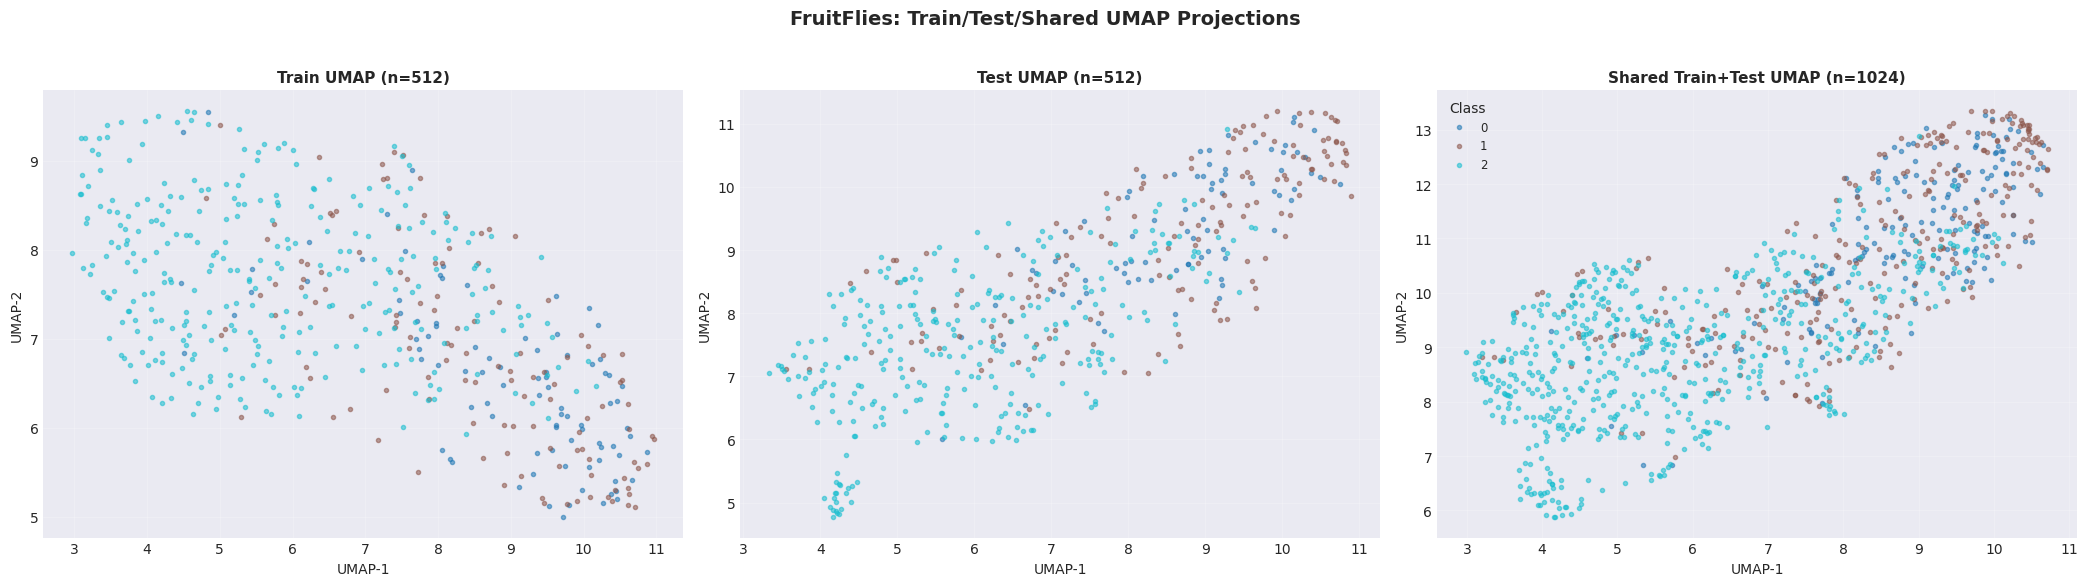

In [5]:

# Train UMAP, test UMAP, and shared UMAP (all class-colored)
# Capped at N_BACKGROUND per split so UMAP remains tractable on FruitFlies.
_rng2   = np.random.default_rng(0)
_n_tr   = len(_train_raw)
_n_te   = len(_test_raw)
_tr_idx = sorted(_rng2.choice(_n_tr, min(N_BACKGROUND, _n_tr), replace=False).tolist())
_te_idx = sorted(_rng2.choice(_n_te, min(N_BACKGROUND, _n_te), replace=False).tolist())

train_series  = np.stack([_downsample_series(to_channel_first(_train_raw[i][0]), DOWNSAMPLE) for i in _tr_idx], axis=0)
test_series   = np.stack([_downsample_series(to_channel_first(_test_raw[i][0]),  DOWNSAMPLE) for i in _te_idx], axis=0)
train_labels  = np.array([to_class_index(_train_raw[i][1]) for i in _tr_idx], dtype=int)
test_labels   = np.array([to_class_index(_test_raw[i][1])  for i in _te_idx], dtype=int)

train_flat    = train_series.reshape(train_series.shape[0], -1)
test_flat     = test_series.reshape(test_series.shape[0], -1)
shared_flat   = np.concatenate([train_flat, test_flat], axis=0)
shared_labels = np.concatenate([train_labels, test_labels], axis=0)

train_reducer = umap.UMAP(
    n_components=2, n_neighbors=min(15, max(2, train_flat.shape[0] - 1)),
    min_dist=0.15, metric='euclidean', random_state=42,
)
test_reducer = umap.UMAP(
    n_components=2, n_neighbors=min(15, max(2, test_flat.shape[0] - 1)),
    min_dist=0.15, metric='euclidean', random_state=42,
)
shared_reducer = umap.UMAP(
    n_components=2, n_neighbors=min(15, max(2, shared_flat.shape[0] - 1)),
    min_dist=0.15, metric='euclidean', random_state=42,
)

train_emb  = train_reducer.fit_transform(train_flat)
test_emb   = test_reducer.fit_transform(test_flat)
shared_emb = shared_reducer.fit_transform(shared_flat)

class_ids  = np.unique(shared_labels)
class_cmap = plt.colormaps['tab10']

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
plot_defs = [
    (axes[0], train_emb,  train_labels,  f'Train UMAP (n={len(train_flat)})'),
    (axes[1], test_emb,   test_labels,   f'Test UMAP (n={len(test_flat)})'),
    (axes[2], shared_emb, shared_labels, f'Shared Train+Test UMAP (n={len(shared_flat)})'),
]

for ax, emb, labels, title in plot_defs:
    for idx, class_id in enumerate(class_ids):
        mask = labels == class_id
        if not np.any(mask):
            continue
        color_val = idx / max(1, len(class_ids) - 1)
        ax.scatter(emb[mask, 0], emb[mask, 1], s=9, alpha=0.55,
                   color=class_cmap(color_val), label=str(class_id))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    ax.grid(True, alpha=0.2)

handles, legend_labels = axes[2].get_legend_handles_labels()
axes[2].legend(handles, legend_labels, loc='best', fontsize='small', title='Class')

fig.suptitle('FruitFlies: Train/Test/Shared UMAP Projections', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.01, 1, 0.96])
plt.show()


In [6]:
print(f"{'iter':>4} {'pred':>5} {'conf':>8} {'target_p':>10} {'l2_to_guide':>14}")
print('-' * 46)
for step in trace_result['history']:
    label_text = 'orig' if step['iteration'] < 0 else str(step['iteration'])
    print(f"{label_text:>4} {step['pred_class']:>5} {step['confidence']:>8.4f} {step['target_prob']:>10.4f} {step['l2_to_guide']:>14.4f}")

iter  pred     conf   target_p    l2_to_guide
----------------------------------------------
orig     1   0.9996     0.0003         1.3621
   0     1   0.9986     0.0011         1.3385
   1     1   0.9900     0.0091         1.3144
   2     1   0.9112     0.0859         1.2896
   3     1   0.5131     0.4812         1.2642
   4     0   0.9097     0.9097         1.2381


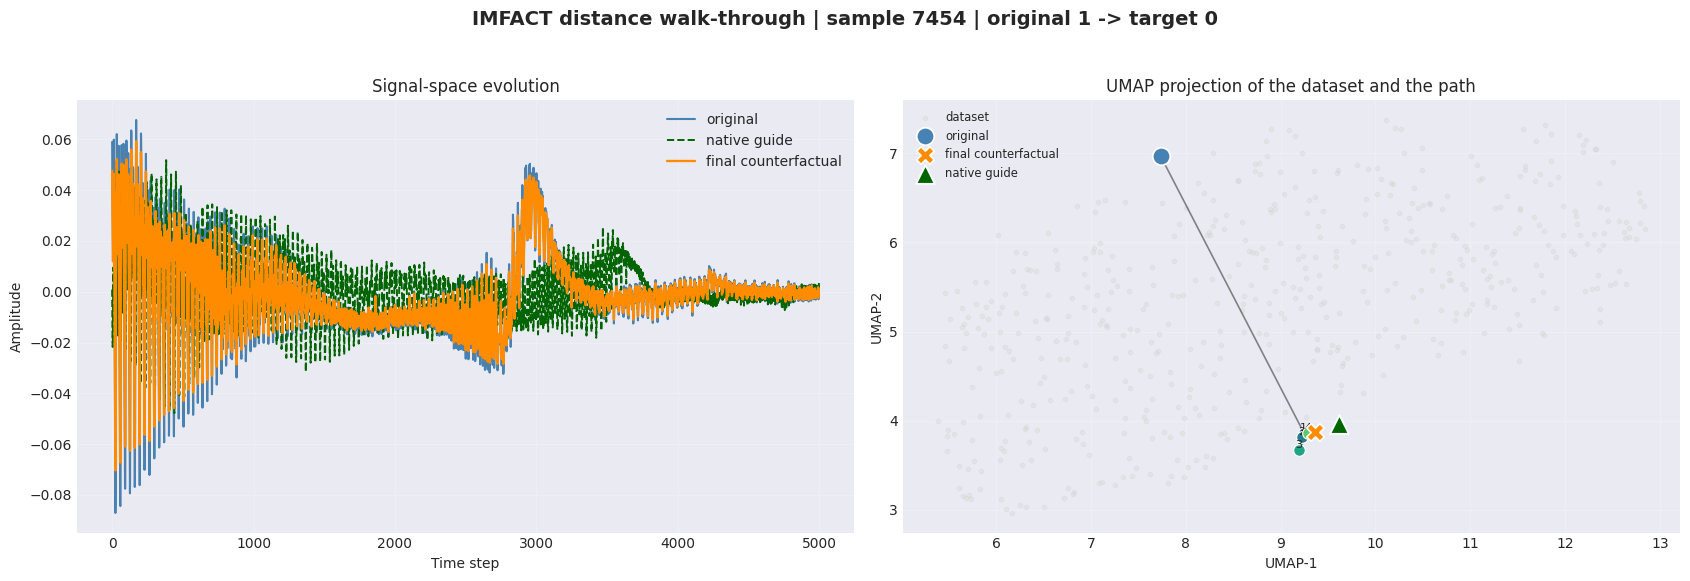

In [7]:
embedding, background_count, path_count = build_umap_embedding(reference_data, trace_result)
background_emb = embedding[:background_count]
path_emb = embedding[background_count:background_count + path_count]
guide_emb = embedding[-1]

sample_cf = to_channel_first(sample)
native_guide_cf = to_channel_first(trace_result['native_guide'])
final_cf = to_channel_first(trace_result['final_cf'])
x = np.arange(sample_cf.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

axes[0].plot(x, sample_cf[0], color='steelblue', linewidth=1.5, label='original')
for step in trace_result['history'][1:-1]:
    axes[0].plot(x, to_channel_first(step['signal'])[0], color='gray', alpha=0.08, linewidth=1.0)
axes[0].plot(x, native_guide_cf[0], color='darkgreen', linestyle='--', linewidth=1.4, label='native guide')
axes[0].plot(x, final_cf[0], color='darkorange', linewidth=1.7, label='final counterfactual')
axes[0].set_title('Signal-space evolution')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('Amplitude')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.2)

axes[1].scatter(background_emb[:, 0], background_emb[:, 1], s=10, c='lightgray', alpha=0.30, label='dataset')
axes[1].plot(path_emb[:, 0], path_emb[:, 1], color='black', alpha=0.45, linewidth=1.2)
step_colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(path_emb)))
for idx, point in enumerate(path_emb):
    if idx == 0:
        axes[1].scatter(point[0], point[1], s=160, c='steelblue', edgecolors='white', linewidths=1.3, zorder=4, label='original')
    elif idx == len(path_emb) - 1:
        axes[1].scatter(point[0], point[1], s=160, c='darkorange', marker='X', edgecolors='white', linewidths=1.2, zorder=5, label='final counterfactual')
    else:
        axes[1].scatter(point[0], point[1], s=70, c=[step_colors[idx]], edgecolors='white', linewidths=0.8, zorder=3)
        axes[1].text(point[0], point[1], str(idx), fontsize=8, ha='center', va='bottom')
axes[1].scatter(guide_emb[0], guide_emb[1], s=180, c='darkgreen', marker='^', edgecolors='white', linewidths=1.3, zorder=5, label='native guide')
axes[1].set_title('UMAP projection of the dataset and the path')
axes[1].set_xlabel('UMAP-1')
axes[1].set_ylabel('UMAP-2')
axes[1].legend(loc='best', fontsize='small')
axes[1].grid(True, alpha=0.2)

fig.suptitle(f'IMFACT distance walk-through | sample {sample_idx} | original {original_class} -> target {target_class}', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

In [8]:
from scipy import signal
from importlib import reload
import cfts.cf_imfact.imfact as imfact_module

reload(imfact_module)
_psd = imfact_module._psd
_sift_imfs = imfact_module._sift_imfs
imfact_cf = imfact_module.imfact_cf
trace_imfact_variant_path = imfact_module.trace_imfact_variant_path

Variant summary
method         original target   native   final    steps  trace = imfact_cf
-------------------------------------------------------------------------
distance       1        0        0        0        5      True          
fingerprint    1        0        0        0        5      True          
variance       1        0        0        0        2      True          
extremes       1        0        0        0        13     True          
maxmin         1        0        0        0        6      True          
coarse_to_fine 1        0        0        1        25     True          


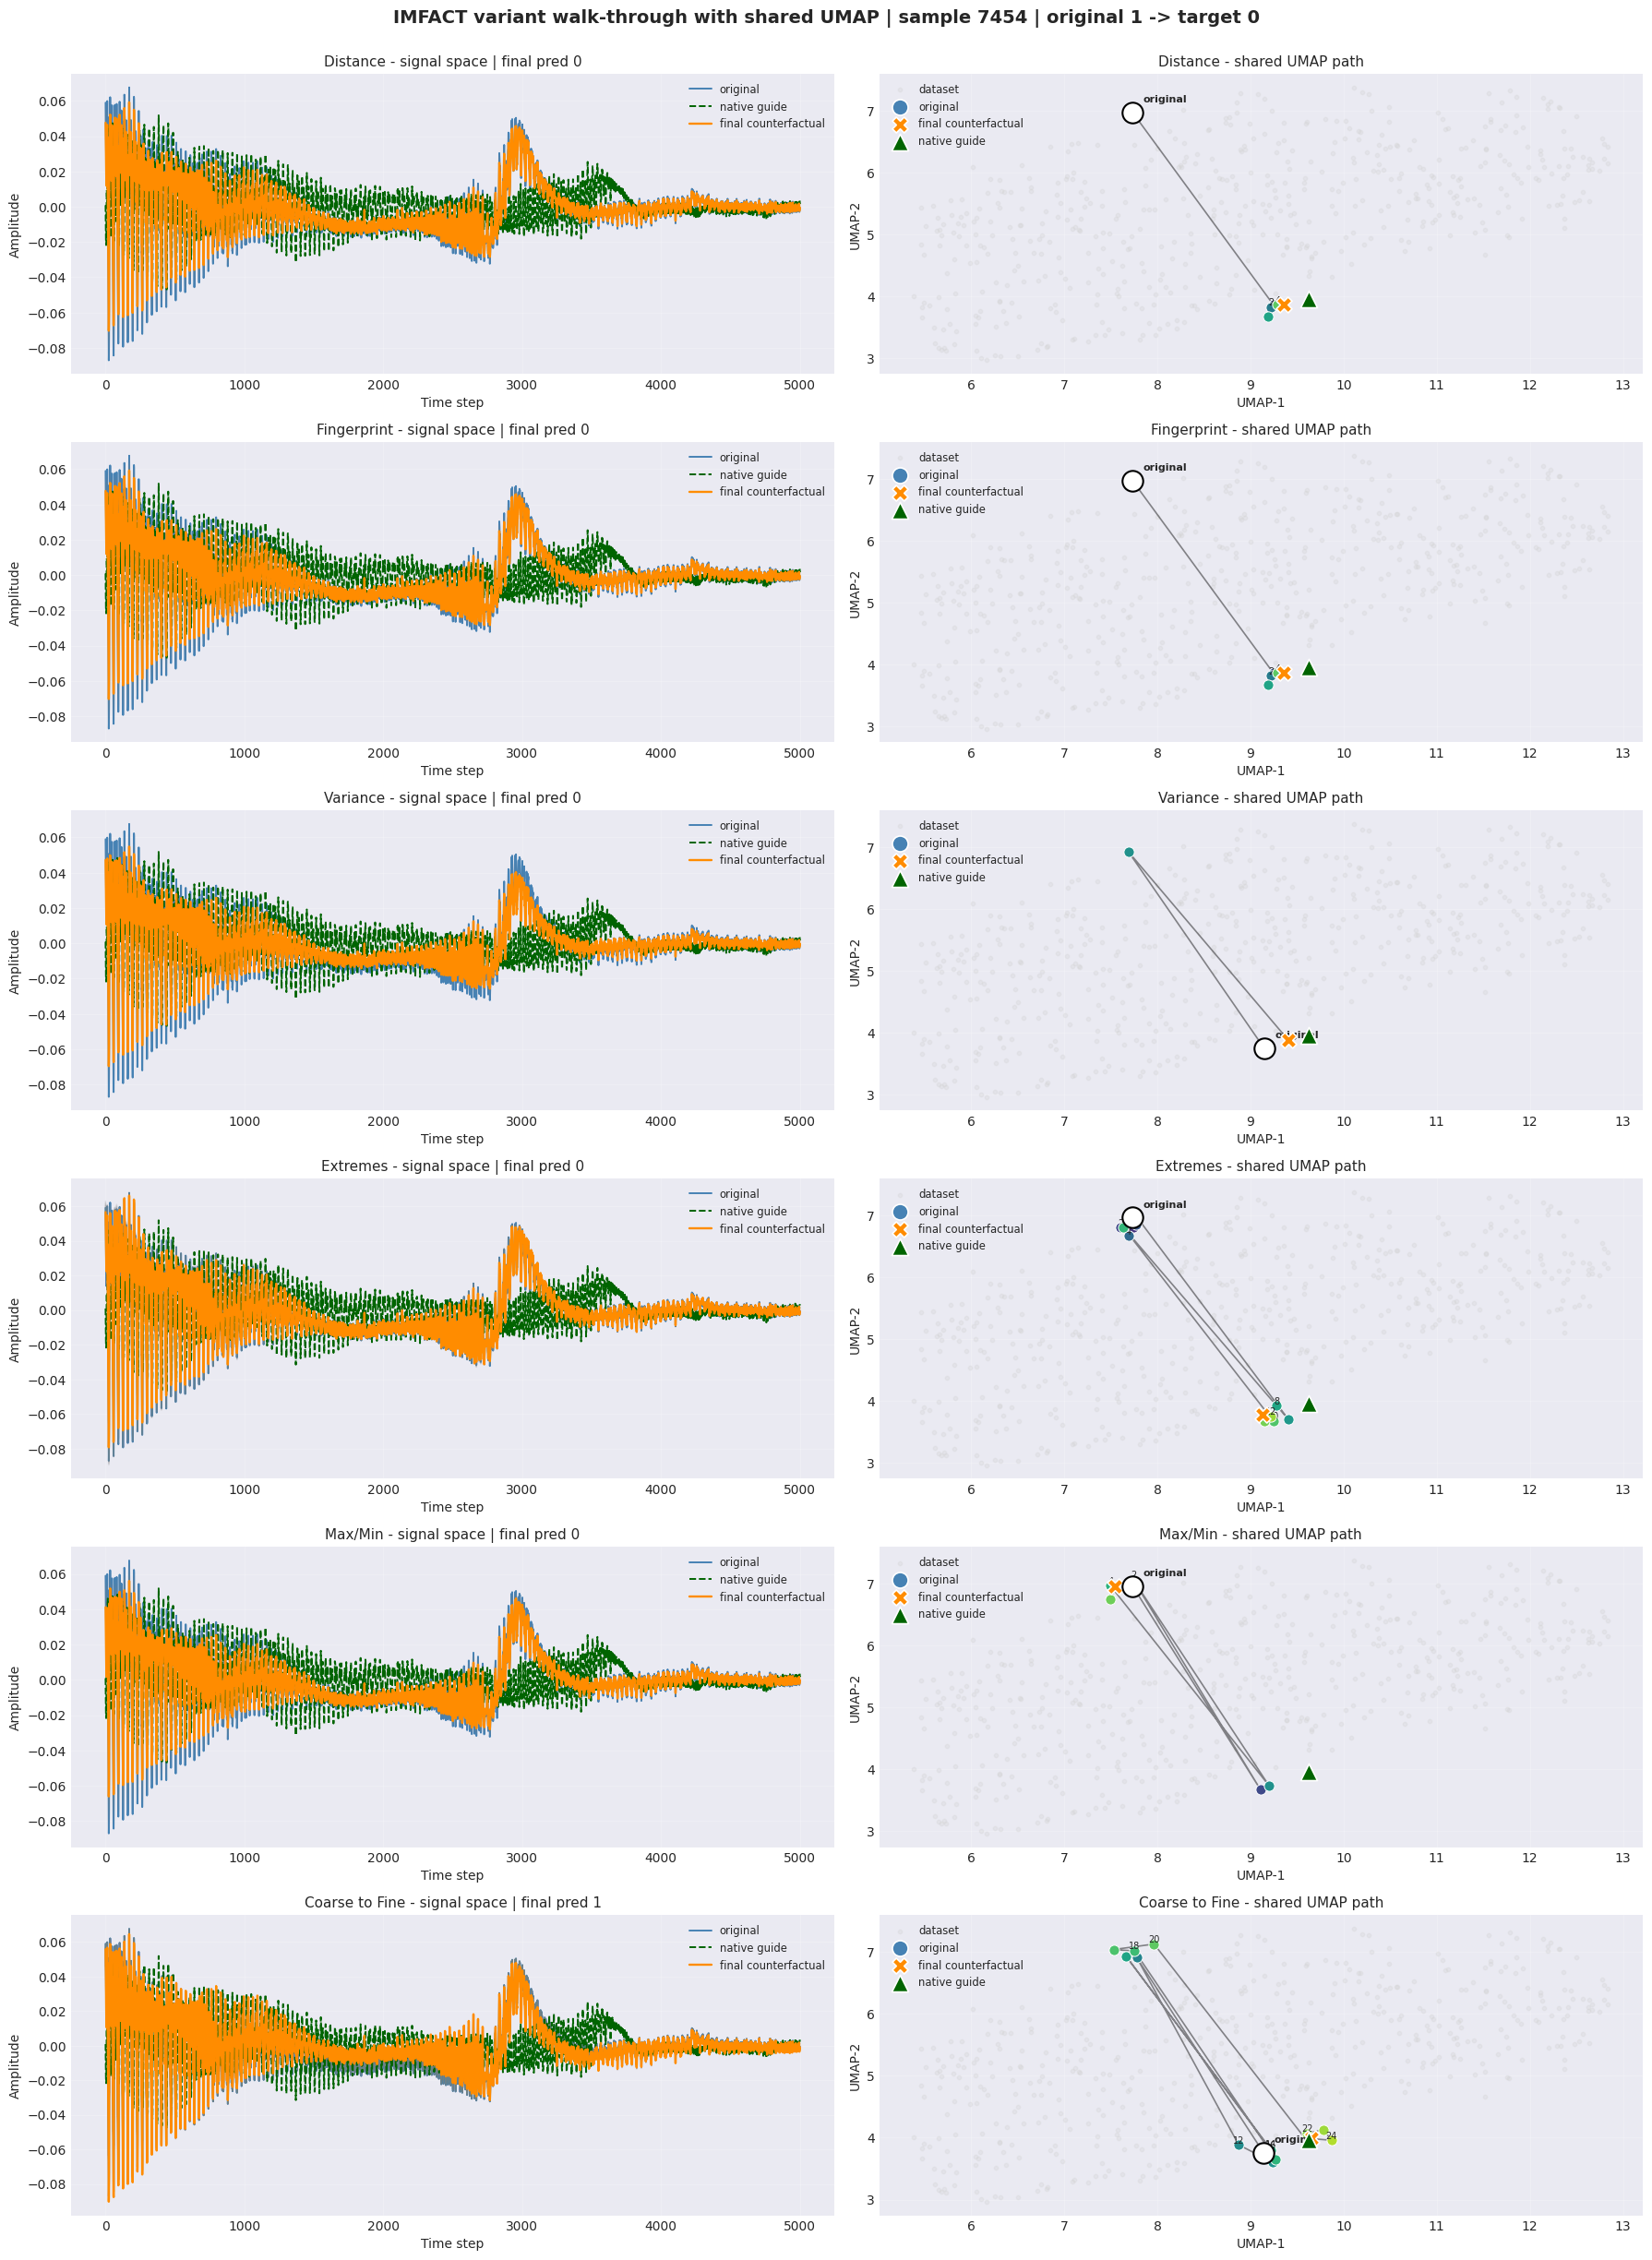

In [9]:
# All IMFACT variants: distance, fingerprint, variance, extremes, maxmin, and coarse_to_fine
# This cell reuses the same query sample and native-guide selection, then
# traces each method and renders its signal-space and UMAP progression.
# All methods now share one common UMAP projection so their paths are directly comparable.

VARIANT_METHODS = ["distance", "fingerprint", "variance", "extremes", "maxmin", "coarse_to_fine"]
VARIANT_TITLES = {
    "distance": "Distance",
    "fingerprint": "Fingerprint",
    "variance": "Variance",
    "extremes": "Extremes",
    "maxmin": "Max/Min",
    "coarse_to_fine": "Coarse to Fine",
}

VARIANT_RUN_CONFIG = {
    "distance": {"step": 0.05, "max_iter": 25},
    "fingerprint": {"step": 0.05, "max_iter": 25},
    "variance": {"step": 0.10, "max_iter": 50},
    "extremes": {"step": 0.05, "max_iter": 25},
    "maxmin": {"step": 0.05, "max_iter": 25},
    "coarse_to_fine": {"step": 0.05, "max_iter": 25},
}



variant_results = {
    method: trace_imfact_variant_path(
        sample,
        model,
        target_class,
        dataset=dataset_test,
        method=method,
        **VARIANT_RUN_CONFIG[method],
        max_imfs=10,
    )
    for method in VARIANT_METHODS
}

print("Variant summary")
print(f"{'method':<14} {'original':<8} {'target':<8} {'native':<8} {'final':<8} {'steps':<6} {'trace = imfact_cf':<14}")
print('-' * 73)
for method in VARIANT_METHODS:
    trace_result = variant_results[method]
    cf_variant, cf_variant_scores = imfact_cf(
        sample,
        model,
        dataset=dataset_test,
        method=method,
        target_class=target_class,
        **VARIANT_RUN_CONFIG[method],
        max_imfs=10,
        verbose=False,
    )
    matches = np.allclose(trace_result["final_cf"], to_channel_first(cf_variant), atol=1e-4)
    print(
        f"{method:<14} {trace_result['original_class']:<8} {trace_result['target_class']:<8} {trace_result['native_guide_label']:<8} {int(np.argmax(trace_result['final_scores'])):<8} "
        f"{len(trace_result['history']) - 1:<6} {str(matches):<14}"
    )

background_flat = reference_data.reshape(reference_data.shape[0], -1)
shared_native_guide = to_channel_first(variant_results[VARIANT_METHODS[0]]["native_guide"]).reshape(1, -1)

n_neighbors = min(15, max(2, background_flat.shape[0] - 1))
shared_reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=0.15, metric="euclidean", random_state=42)
background_emb = shared_reducer.fit_transform(background_flat)
guide_emb = shared_reducer.transform(shared_native_guide)[0]

path_embeddings = {}
for method in VARIANT_METHODS:
    path_flat = np.stack(
        [to_channel_first(step_state["signal"]).reshape(-1) for step_state in variant_results[method]["history"]],
        axis=0,
    )
    path_embeddings[method] = shared_reducer.transform(path_flat)

n_methods = len(VARIANT_METHODS)
fig, axes = plt.subplots(n_methods, 2, figsize=(18, 4.2 * n_methods))
if n_methods == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, method in enumerate(VARIANT_METHODS):
    trace_result = variant_results[method]
    path_emb = path_embeddings[method]

    sample_cf = to_channel_first(sample)
    native_guide_cf = to_channel_first(trace_result["native_guide"])
    final_cf = to_channel_first(trace_result["final_cf"])
    x = np.arange(sample_cf.shape[1])

    signal_ax = axes[row_idx, 0]
    signal_ax.plot(x, sample_cf[0], color="steelblue", linewidth=1.4, label="original")
    for step_state in trace_result["history"][1:-1]:
        signal_ax.plot(x, to_channel_first(step_state["signal"])[0], color="gray", alpha=0.08, linewidth=1.0)
    signal_ax.plot(x, native_guide_cf[0], color="darkgreen", linestyle="--", linewidth=1.4, label="native guide")
    signal_ax.plot(x, final_cf[0], color="darkorange", linewidth=1.7, label="final counterfactual")
    signal_ax.set_title(
        f"{VARIANT_TITLES[method]} - signal space | final pred {trace_result['history'][-1]['pred_class']}",
        fontsize=11,
    )
    signal_ax.set_xlabel("Time step")
    signal_ax.set_ylabel("Amplitude")
    signal_ax.legend(loc="upper right", fontsize="small")
    signal_ax.grid(True, alpha=0.2)

    umap_ax = axes[row_idx, 1]
    umap_ax.scatter(background_emb[:, 0], background_emb[:, 1], s=10, c="lightgray", alpha=0.28, label="dataset")
    umap_ax.plot(path_emb[:, 0], path_emb[:, 1], color="black", alpha=0.45, linewidth=1.2)
    step_colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(path_emb)))
    for step_idx, point in enumerate(path_emb):
        if step_idx == 0:
            umap_ax.scatter(point[0], point[1], s=150, c="steelblue", edgecolors="white", linewidths=1.2, zorder=4, label="original")
        elif step_idx == len(path_emb) - 1:
            umap_ax.scatter(point[0], point[1], s=150, c="darkorange", marker="X", edgecolors="white", linewidths=1.2, zorder=5, label="final counterfactual")
        else:
            umap_ax.scatter(point[0], point[1], s=65, c=[step_colors[step_idx]], edgecolors="white", linewidths=0.7, zorder=3)
            if step_idx % 2 == 0:
                umap_ax.text(point[0], point[1], str(step_idx), fontsize=7, ha="center", va="bottom")
    if len(path_emb) > 0:
        umap_ax.scatter(path_emb[0, 0], path_emb[0, 1], s=260, c="white", edgecolors="black", linewidths=1.5, zorder=6)
        umap_ax.annotate("original", xy=(path_emb[0, 0], path_emb[0, 1]), xytext=(8, 8), textcoords="offset points", fontsize=8, fontweight="bold")
    umap_ax.scatter(guide_emb[0], guide_emb[1], s=170, c="darkgreen", marker="^", edgecolors="white", linewidths=1.2, zorder=5, label="native guide")
    umap_ax.set_title(f"{VARIANT_TITLES[method]} - shared UMAP path", fontsize=11)
    umap_ax.set_xlabel("UMAP-1")
    umap_ax.set_ylabel("UMAP-2")
    umap_ax.legend(loc="best", fontsize="small")
    umap_ax.grid(True, alpha=0.2)

fig.suptitle(
    f"IMFACT variant walk-through with shared UMAP | sample {sample_idx} | original {original_class} -> target {target_class}",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0.01, 1, 0.98])
plt.show()


Final-counterfactual proximity metrics by variant
method         success  l2_norm      dtw_norm     zscore_l2    manhattan    l0_norm    compactness 
----------------------------------------------------------------------------------------------------
distance       True     0.163077     0.150282     10.194992    6.512387     4993.0     0.991000    
fingerprint    True     0.163077     0.150282     10.194992    6.512387     4993.0     0.991000    
variance       True     0.228925     0.177812     14.311593    11.121530    4998.0     0.984400    
extremes       True     0.115468     0.107686     7.218683     4.873237     4999.0     0.999200    
maxmin         True     0.222072     0.179918     13.883154    8.888155     4995.0     0.977600    
coarse_to_fine False    0.244933     0.151828     15.312352    13.961744    5000.0     1.000000    

Canonical CF-evaluation dimensions by variant
method         validity↑    proximity↓   sparsity↑    plausibility↑ 
---------------------------------

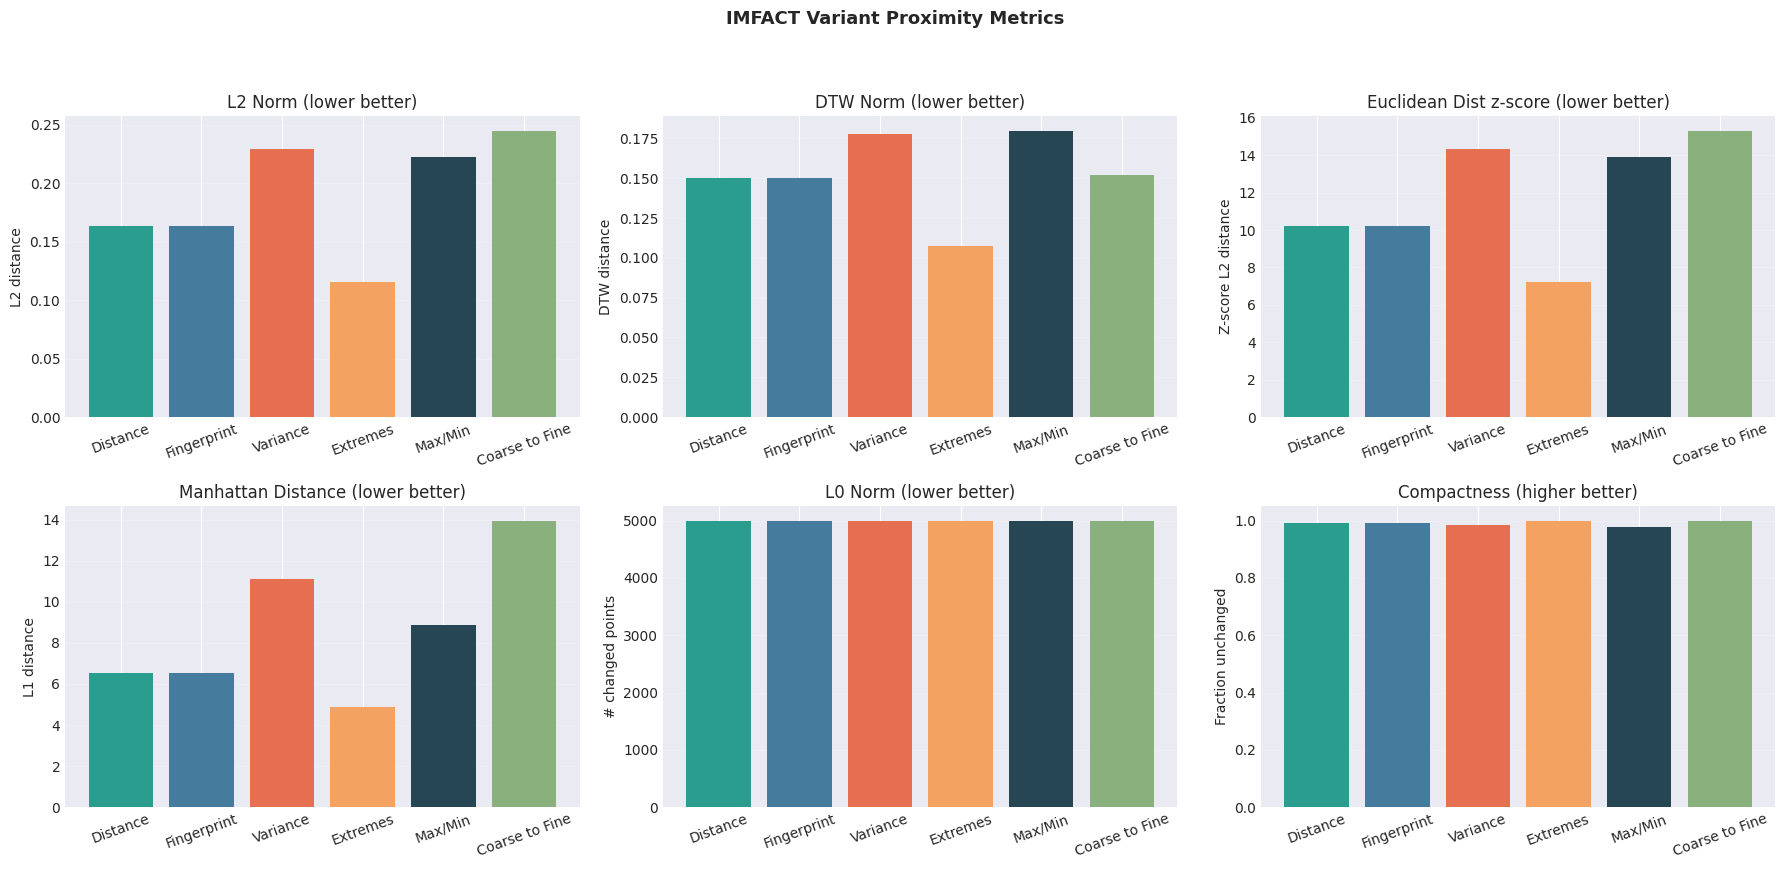

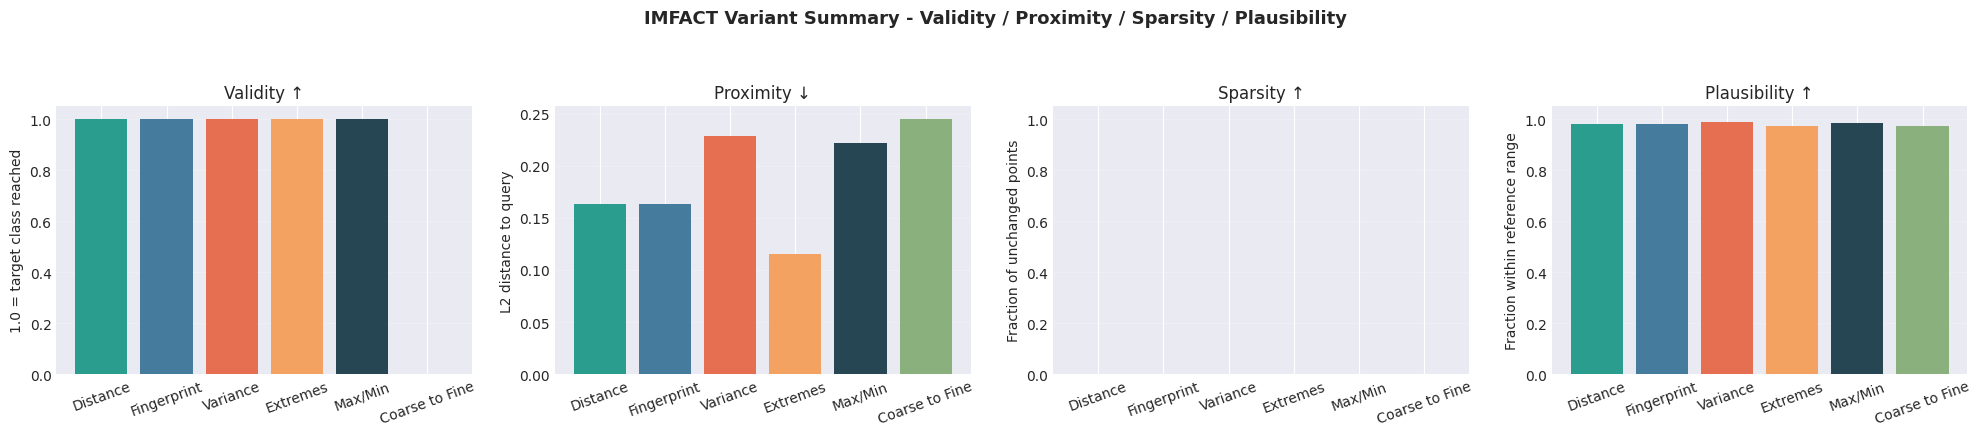

In [10]:
from cfts.metrics import evaluate_counterfactual

# Quantify final counterfactual quality for each IMFACT variant across the four
# canonical CF-evaluation dimensions: validity (higher better), proximity (lower
# better), sparsity (higher better), plausibility (higher better).
query_cf = to_channel_first(sample)
variant_metric_rows = []


def _model_fn(x):
    return predict_scores(model, np.asarray(x, dtype=np.float32), device)


for method in VARIANT_METHODS:
    trace_result = variant_results[method]
    final_cf = to_channel_first(trace_result["final_cf"])

    metrics = evaluate_counterfactual(
        query_cf, final_cf,
        model=_model_fn, target_class=int(trace_result["target_class"]),
        reference_data=reference_data,
        dtw_max_length=None,
    )
    l2_val = metrics["l2_distance"]
    dtw_val = metrics["dtw_distance"]

    variant_metric_rows.append(
        {
            "method": method,
            "title": VARIANT_TITLES[method],
            "final_pred": int(np.argmax(trace_result["final_scores"])),
            "target_class": int(trace_result["target_class"]),
            "success": bool(int(np.argmax(trace_result["final_scores"])) == int(trace_result["target_class"])),
            "l2_norm": l2_val,
            "dtw_norm": dtw_val,
            "l2_score": 1.0 / (1.0 + l2_val),
            "dtw_score": 1.0 / (1.0 + dtw_val),
            "euclidean_dist_zscore": metrics["euclidean_dist_zscore"],
            "manhattan_distance": metrics["manhattan_distance"],
            "l0_norm": metrics["l0_norm"],
            "compactness": metrics["compactness"],
            "validity": metrics["validity"],
            "proximity": l2_val,
            "sparsity": metrics["sparsity"],
            "plausibility": metrics.get("range_validity", float("nan")),
        }
    )

print("Final-counterfactual proximity metrics by variant")
print(
    f"{'method':<14} {'success':<8} {'l2_norm':<12} {'dtw_norm':<12} "
    f"{'zscore_l2':<12} {'manhattan':<12} {'l0_norm':<10} {'compactness':<12}"
)
print("-" * 100)
for row in variant_metric_rows:
    print(
        f"{row['method']:<14} {str(row['success']):<8} "
        f"{row['l2_norm']:<12.6f} {row['dtw_norm']:<12.6f} "
        f"{row['euclidean_dist_zscore']:<12.6f} {row['manhattan_distance']:<12.6f} "
        f"{row['l0_norm']:<10.1f} {row['compactness']:<12.6f}"
    )

print("\nCanonical CF-evaluation dimensions by variant")
print(
    f"{'method':<14} {'validity↑':<12} {'proximity↓':<12} "
    f"{'sparsity↑':<12} {'plausibility↑':<14}"
)
print("-" * 66)
for row in variant_metric_rows:
    print(
        f"{row['method']:<14} {row['validity']:<12.4f} {row['proximity']:<12.6f} "
        f"{row['sparsity']:<12.4f} {row['plausibility']:<14.4f}"
    )

methods = [row["title"] for row in variant_metric_rows]
l2_vals = [row["l2_norm"] for row in variant_metric_rows]
dtw_vals = [row["dtw_norm"] for row in variant_metric_rows]
zscore_vals = [row["euclidean_dist_zscore"] for row in variant_metric_rows]
manhattan_vals = [row["manhattan_distance"] for row in variant_metric_rows]
l0_vals = [row["l0_norm"] for row in variant_metric_rows]
compactness_vals = [row["compactness"] for row in variant_metric_rows]
validity_vals = [row["validity"] for row in variant_metric_rows]
proximity_vals = [row["proximity"] for row in variant_metric_rows]
sparsity_vals = [row["sparsity"] for row in variant_metric_rows]
plausibility_vals = [row["plausibility"] for row in variant_metric_rows]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
bar_colors = ["#2a9d8f", "#457b9d", "#e76f51", "#f4a261", "#264653", "#8ab17d"]

axes[0, 0].bar(methods, l2_vals, color=bar_colors)
axes[0, 0].set_title("L2 Norm (lower better)")
axes[0, 0].set_ylabel("L2 distance")
axes[0, 0].tick_params(axis="x", rotation=20)
axes[0, 0].grid(True, axis="y", alpha=0.2)

axes[0, 1].bar(methods, dtw_vals, color=bar_colors)
axes[0, 1].set_title("DTW Norm (lower better)")
axes[0, 1].set_ylabel("DTW distance")
axes[0, 1].tick_params(axis="x", rotation=20)
axes[0, 1].grid(True, axis="y", alpha=0.2)

axes[0, 2].bar(methods, zscore_vals, color=bar_colors)
axes[0, 2].set_title("Euclidean Dist z-score (lower better)")
axes[0, 2].set_ylabel("Z-score L2 distance")
axes[0, 2].tick_params(axis="x", rotation=20)
axes[0, 2].grid(True, axis="y", alpha=0.2)

axes[1, 0].bar(methods, manhattan_vals, color=bar_colors)
axes[1, 0].set_title("Manhattan Distance (lower better)")
axes[1, 0].set_ylabel("L1 distance")
axes[1, 0].tick_params(axis="x", rotation=20)
axes[1, 0].grid(True, axis="y", alpha=0.2)

axes[1, 1].bar(methods, l0_vals, color=bar_colors)
axes[1, 1].set_title("L0 Norm (lower better)")
axes[1, 1].set_ylabel("# changed points")
axes[1, 1].tick_params(axis="x", rotation=20)
axes[1, 1].grid(True, axis="y", alpha=0.2)

axes[1, 2].bar(methods, compactness_vals, color=bar_colors)
axes[1, 2].set_title("Compactness (higher better)")
axes[1, 2].set_ylabel("Fraction unchanged")
axes[1, 2].tick_params(axis="x", rotation=20)
axes[1, 2].grid(True, axis="y", alpha=0.2)

fig.suptitle("IMFACT Variant Proximity Metrics", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.02, 1, 0.94])
plt.show()

fig2, axes2 = plt.subplots(1, 4, figsize=(20, 4.5))

axes2[0].bar(methods, validity_vals, color=bar_colors)
axes2[0].set_title("Validity ↑")
axes2[0].set_ylabel("1.0 = target class reached")
axes2[0].set_ylim(0, 1.05)
axes2[0].tick_params(axis="x", rotation=20)
axes2[0].grid(True, axis="y", alpha=0.2)

axes2[1].bar(methods, proximity_vals, color=bar_colors)
axes2[1].set_title("Proximity ↓")
axes2[1].set_ylabel("L2 distance to query")
axes2[1].tick_params(axis="x", rotation=20)
axes2[1].grid(True, axis="y", alpha=0.2)

axes2[2].bar(methods, sparsity_vals, color=bar_colors)
axes2[2].set_title("Sparsity ↑")
axes2[2].set_ylabel("Fraction of unchanged points")
axes2[2].set_ylim(0, 1.05)
axes2[2].tick_params(axis="x", rotation=20)
axes2[2].grid(True, axis="y", alpha=0.2)

axes2[3].bar(methods, plausibility_vals, color=bar_colors)
axes2[3].set_title("Plausibility ↑")
axes2[3].set_ylabel("Fraction within reference range")
axes2[3].set_ylim(0, 1.05)
axes2[3].tick_params(axis="x", rotation=20)
axes2[3].grid(True, axis="y", alpha=0.2)

fig2.suptitle("IMFACT Variant Summary - Validity / Proximity / Sparsity / Plausibility", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.show()

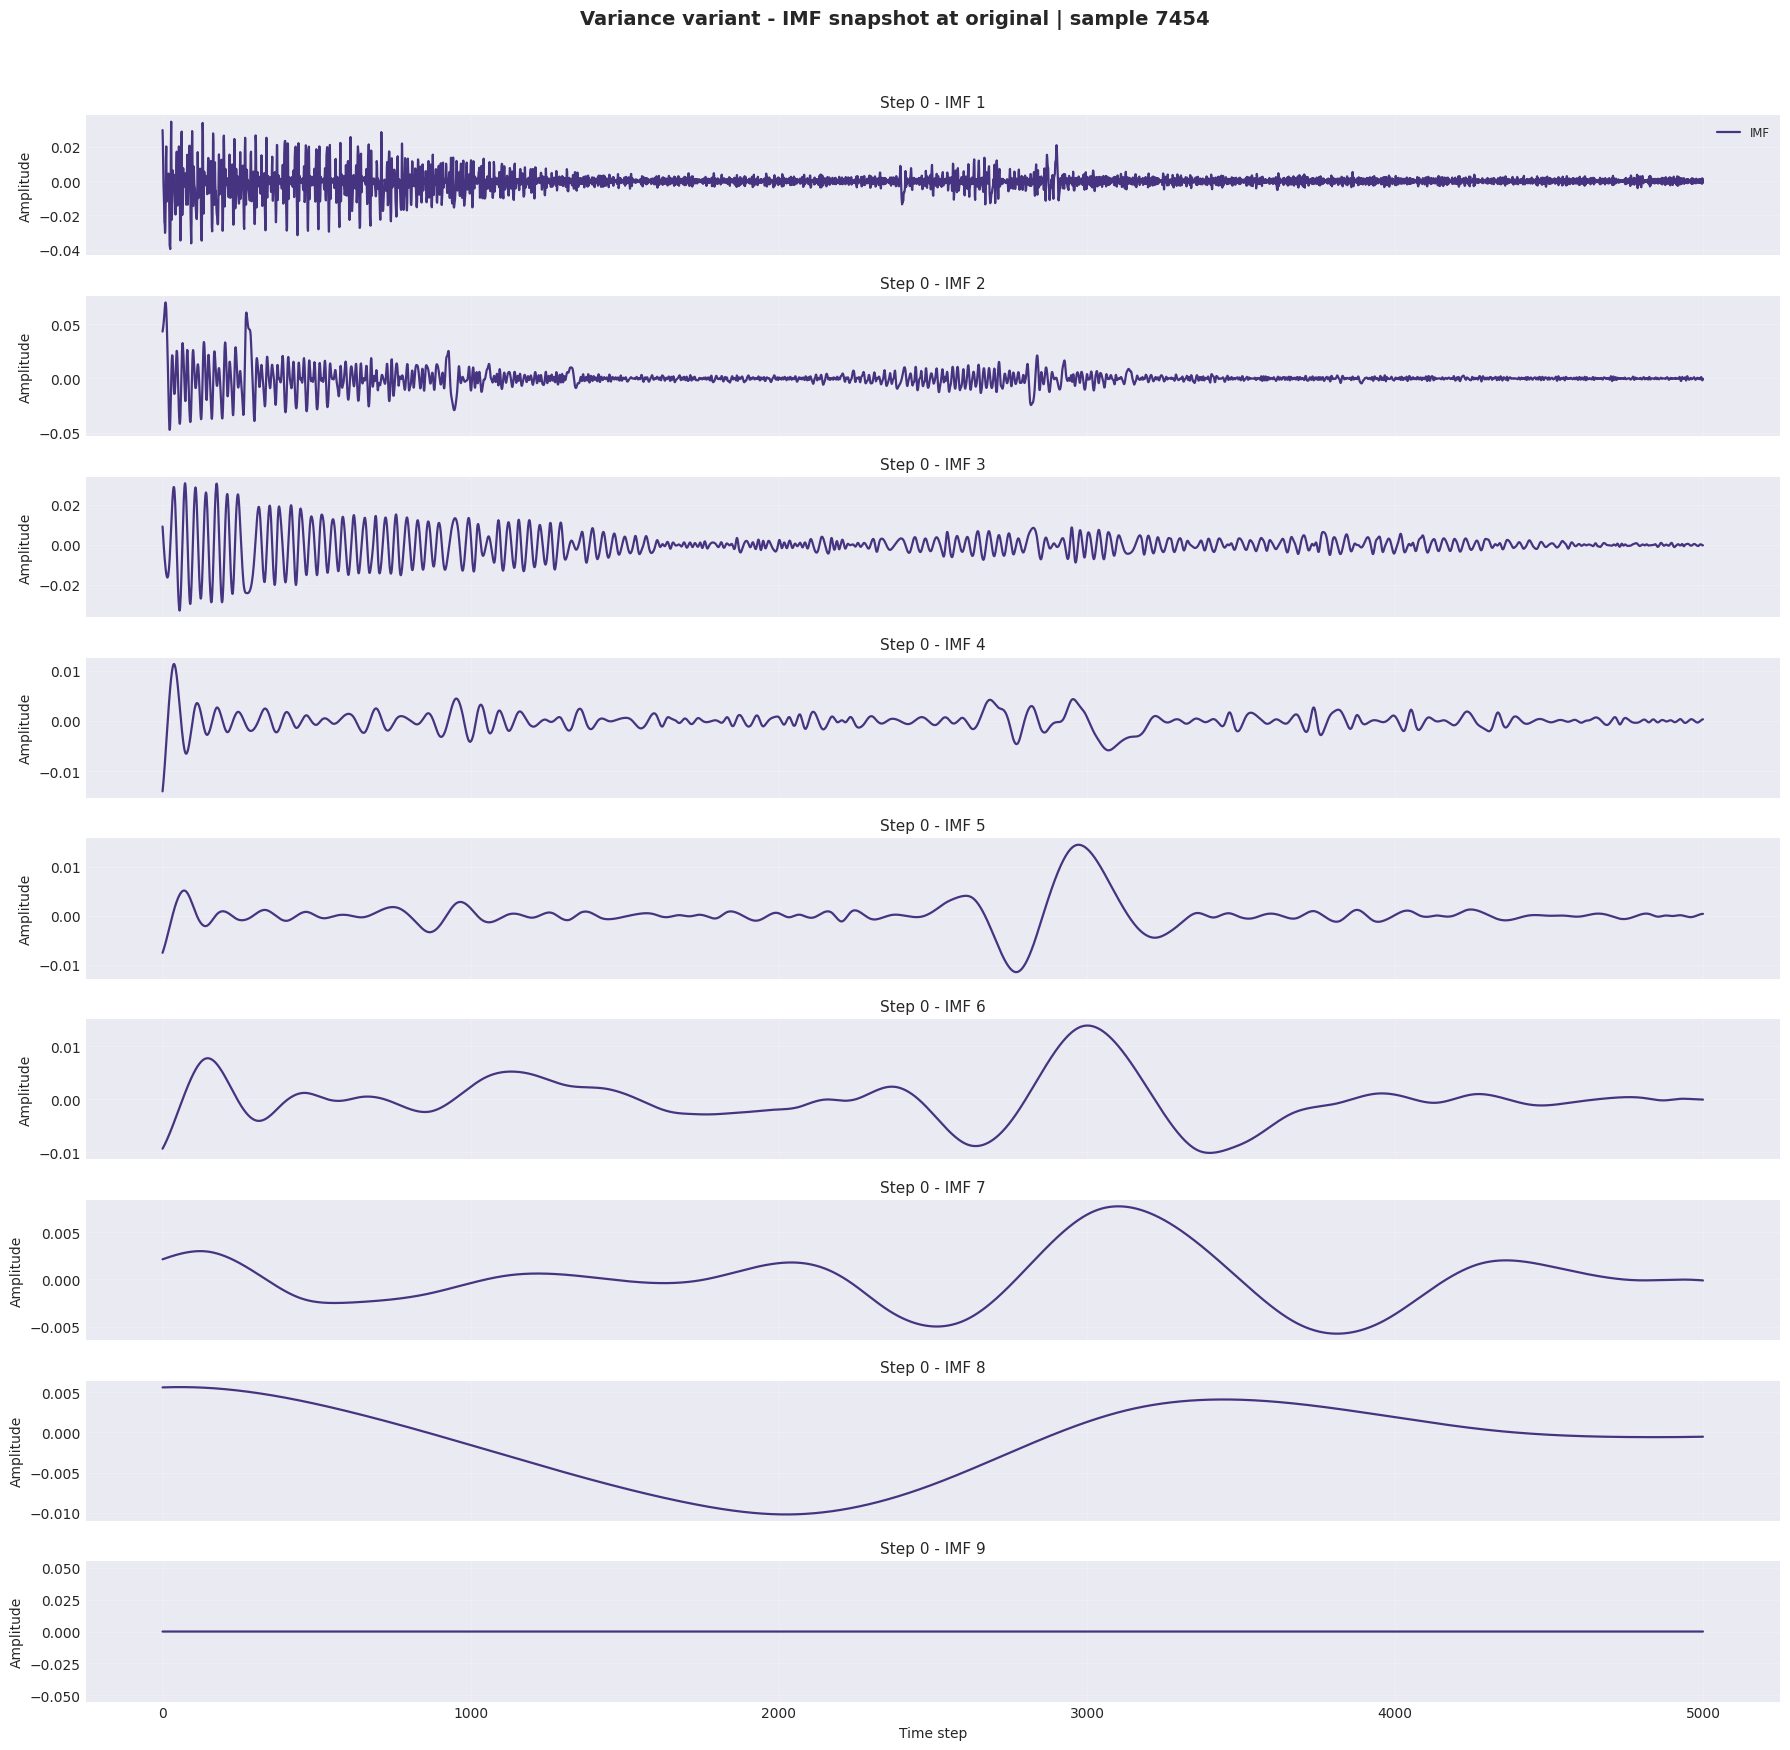

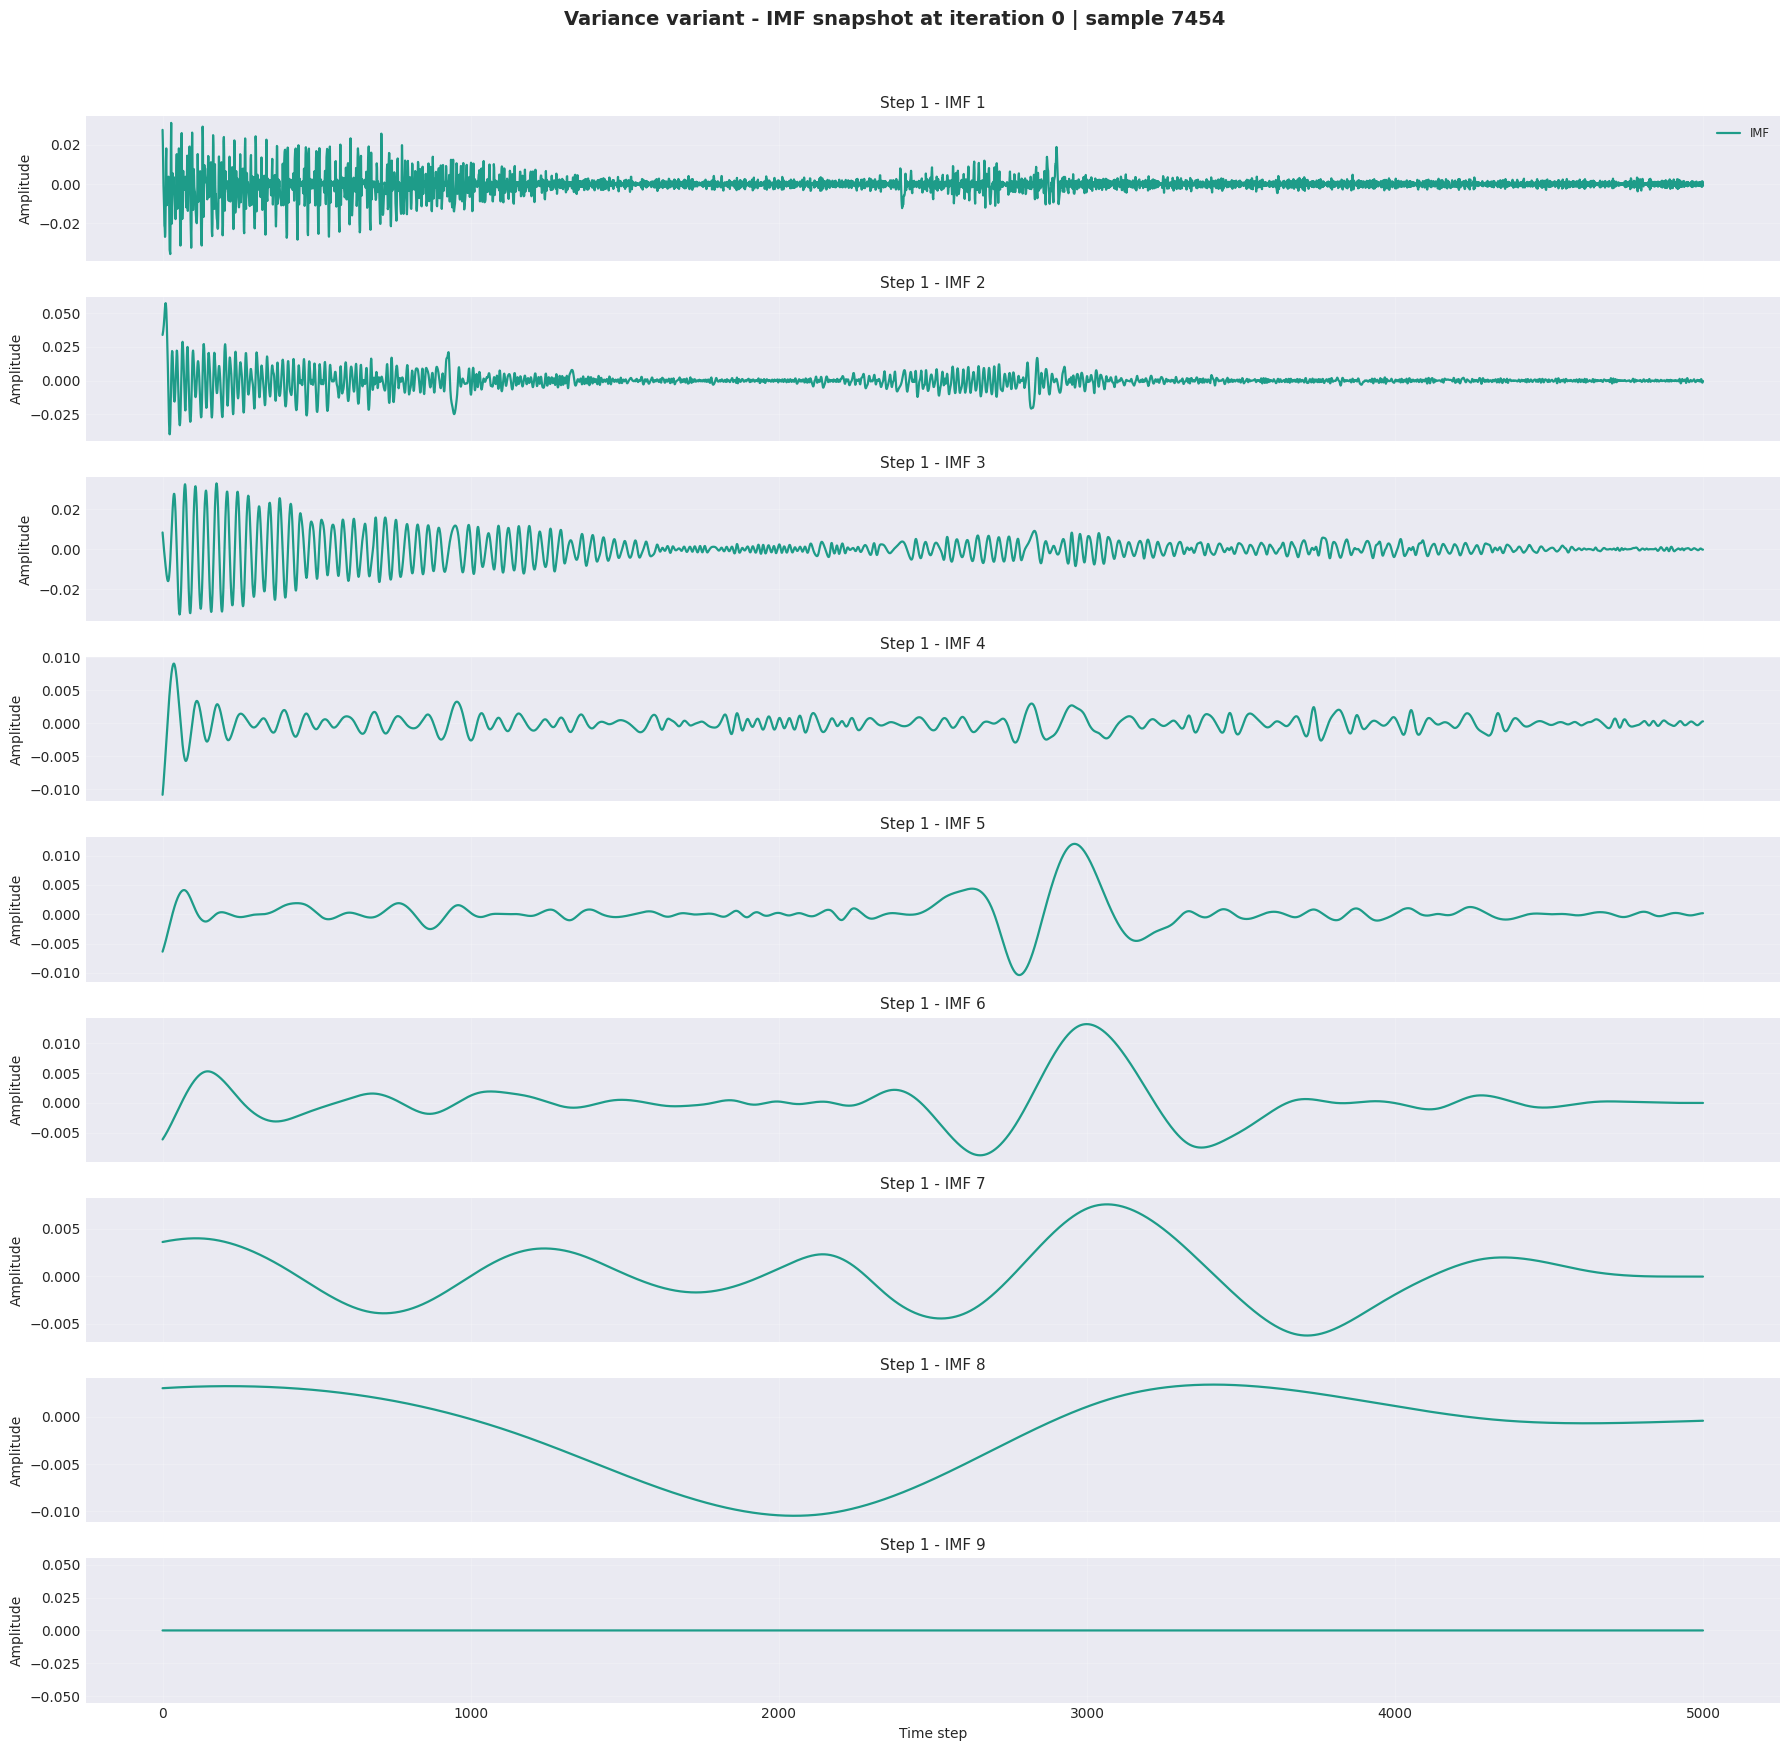

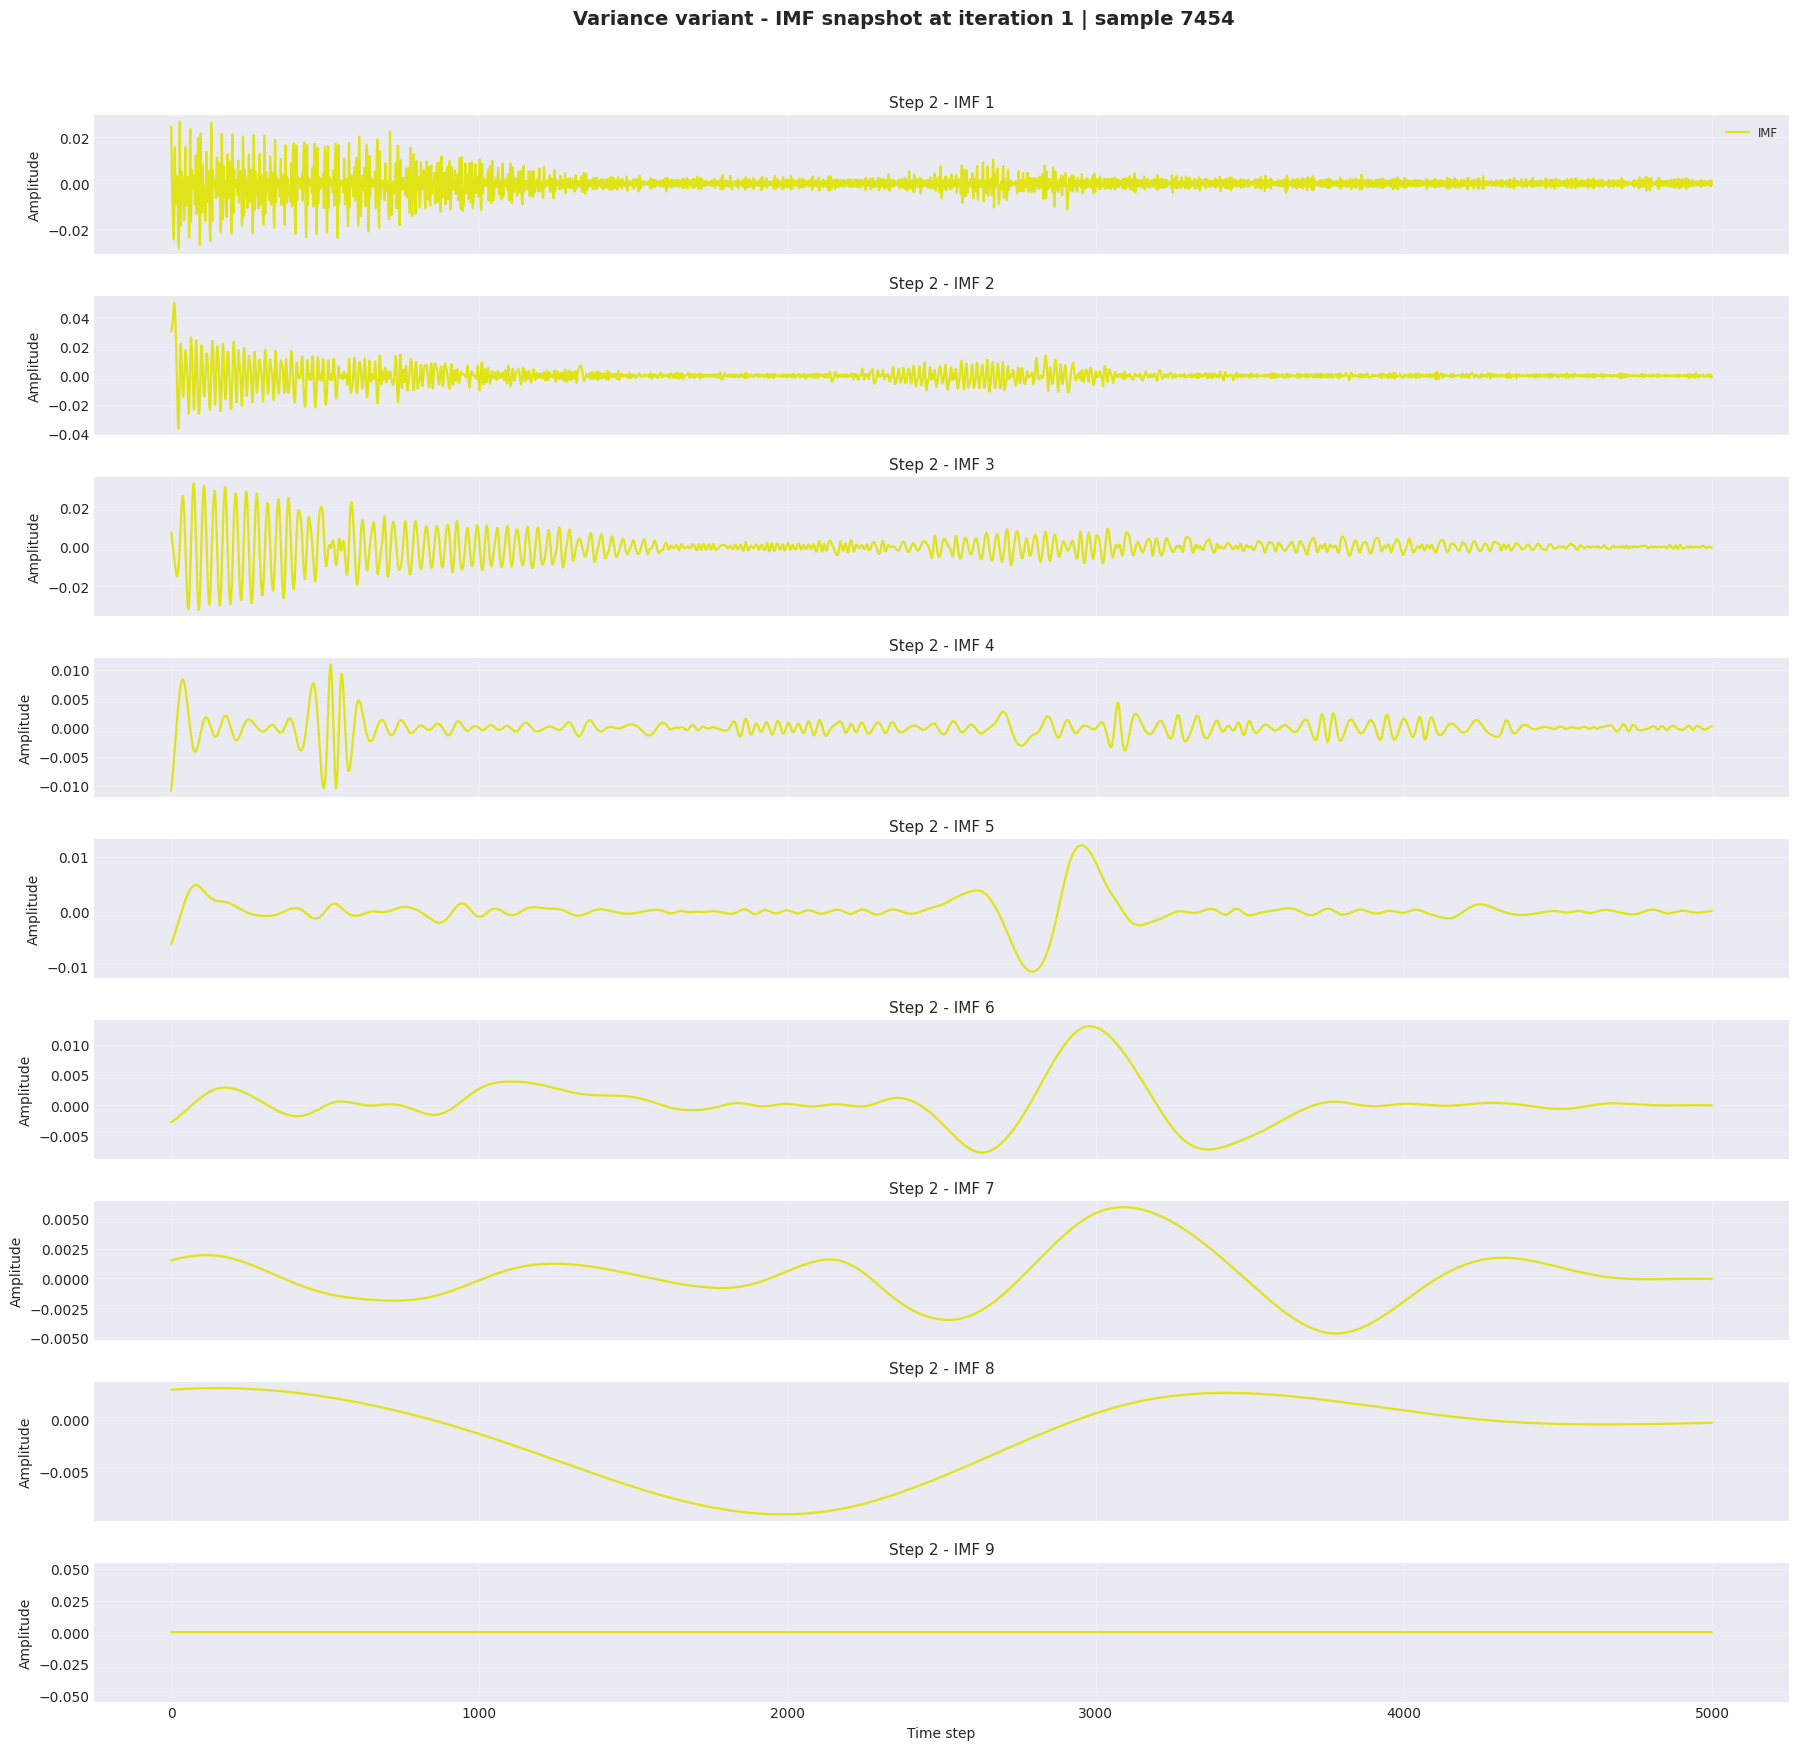

In [11]:
# Variance-mode step-by-step IMF plots
# Each reconstruction step gets its own figure so the evolution can be inspected one step at a time.

variance_trace = variant_results["variance"]
variance_history = variance_trace["history"]
variance_signals = [to_channel_first(step_state["signal"])[0] for step_state in variance_history]
variance_imfs = [_sift_imfs(signal, max_imfs=10) for signal in variance_signals]
time_axis = np.arange(variance_signals[0].shape[0])
step_positions = np.linspace(0.15, 0.95, len(variance_history))
step_colors = plt.cm.viridis(step_positions)

for step_idx, (step_state, imfs) in enumerate(zip(variance_history, variance_imfs)):
    n_imfs = imfs.shape[0]
    fig, axes = plt.subplots(n_imfs, 1, figsize=(18, 2.0 * n_imfs), sharex=True)
    if n_imfs == 1:
        axes = [axes]

    for imf_idx, ax in enumerate(axes):
        ax.plot(
            time_axis,
            imfs[imf_idx],
            color=step_colors[step_idx],
            linewidth=1.6,
        )
        ax.set_title(f"Step {step_idx} - IMF {imf_idx + 1}", fontsize=11)
        ax.set_ylabel("Amplitude")
        ax.grid(True, alpha=0.2)
        if imf_idx == 0:
            ax.legend(["IMF"], loc="upper right", fontsize="small")

    axes[-1].set_xlabel("Time step")
    step_label = "original" if step_state["iteration"] < 0 else f"iteration {step_state['iteration']}"
    fig.suptitle(
        f"Variance variant - IMF snapshot at {step_label} | sample {sample_idx}",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout(rect=[0, 0.01, 1, 0.96])
    plt.show()
